In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
mean_squared_error,
mean_absolute_error,
r2_score
)

In [56]:
df = pd.read_csv("../dataset/medical_insurance_encoded.csv")

In [57]:
df.head()

,cat__sex_male,cat__smoker_yes,cat__region_northwest,cat__region_southeast,cat__region_southwest,remainder__age,remainder__bmi,remainder__children,remainder__smoker_bmi,remainder__age_squared,remainder__age_smoker,remainder__is_underweight,remainder__is_obese,remainder__obese_smoker,remainder__children_smoker,charges
0,0.0,1.0,0.0,0.0,1.0,19.0,27.900,0.0,27.9,361.0,19.0,0.0,0.0,0.0,0.0,16884.92400
1,1.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0,0.0,324.0,0.0,0.0,1.0,0.0,0.0,1725.55230
2,1.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0,0.0,784.0,0.0,0.0,1.0,0.0,0.0,4449.46200
3,1.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0,0.0,1089.0,0.0,0.0,0.0,0.0,0.0,21984.47061
4,1.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0,0.0,1024.0,0.0,0.0,0.0,0.0,0.0,3866.85520


In [58]:
x = df.drop("charges", axis=1)
y = df["charges"]
print(x.head())
print(y.head())

   cat__sex_male  cat__smoker_yes  cat__region_northwest  \
0            0.0              1.0                    0.0   
1            1.0              0.0                    0.0   
2            1.0              0.0                    0.0   
3            1.0              0.0                    1.0   
4            1.0              0.0                    1.0   

   cat__region_southeast  cat__region_southwest  remainder__age  \
0                    0.0                    1.0            19.0   
1                    1.0                    0.0            18.0   
2                    1.0                    0.0            28.0   
3                    0.0                    0.0            33.0   
4                    0.0                    0.0            32.0   

   remainder__bmi  remainder__children  remainder__smoker_bmi  \
0          27.900                  0.0                   27.9   
1          33.770                  1.0                    0.0   
2          33.000                  3.0   

In [59]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
svr = SVR(kernel='rbf', C=100000, gamma=0.1, epsilon=0.1)
svr.fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel='rbf', C=100000, gamma=0.1, epsilon=0.1))
])
cv_scores = cross_val_score(svr_pipeline, x, y, cv=5, scoring='r2')

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 :", r2)
print("R² per fold:", cv_scores)
print(f"Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# param_grid= {
#     'kernel': ['rbf'],
#     'C': [1, 10000, 10000, 100000,100],
#     'gamma': ['scale',0.1, 0.01, 0.001, 0.0001],
#     'epsilon': [0.01, 0.1, 0.5, 1, 1.5]
# }

In [ ]:
# grid_search = GridSearchCV(estimator=SVR(), param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=2)

In [ ]:
# grid_search.fit(X_train_scaled, y_train)

In [ ]:
import joblib

joblib.dump(scaler, "../models/svr_scaler.pkl")
joblib.dump(svr, "../models/svr_rbf_model.pkl")

['../models/svr_rbf_model.pkl']

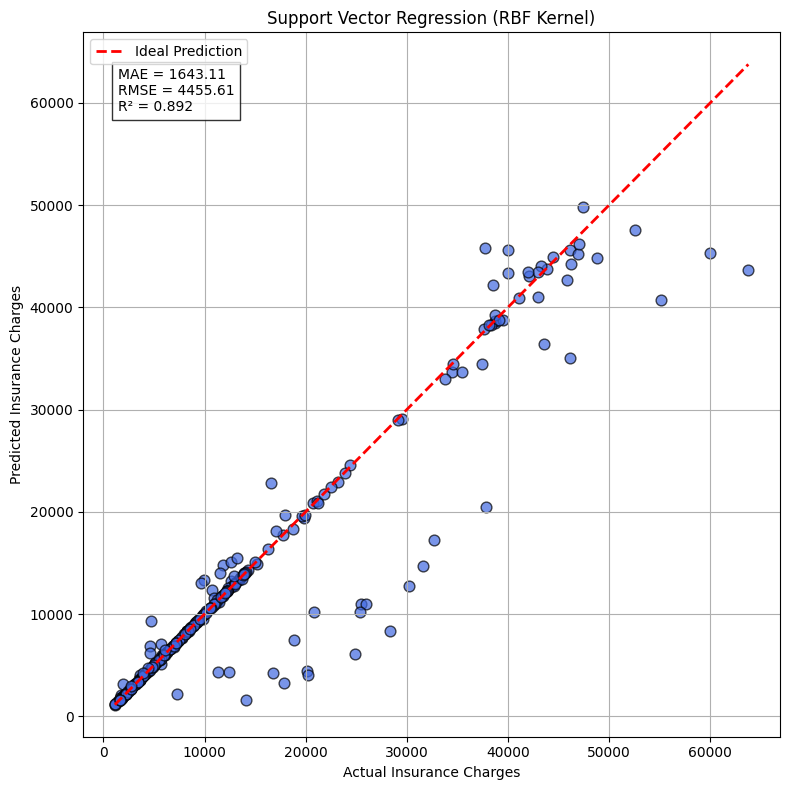

In [ ]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    color='royalblue',
    edgecolor='black',
    alpha=0.7,
    s=60
)

# Perfect prediction line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Ideal Prediction'
)

plt.xlabel("Actual Insurance Charges")
plt.ylabel("Predicted Insurance Charges")
plt.title("Support Vector Regression (RBF Kernel)")
plt.legend()
plt.grid(True)

# Display metrics
plt.text(
    0.05,
    0.95,
    f"MAE = {mae:.2f}\nRMSE = {rmse:.2f}\nR² = {r2:.3f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

R² per fold: [0.87421674 0.78379713 0.88228317 0.84034116 0.84206635]
Mean R²: 0.8445 ± 0.0347
